In [1]:
# loads numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import torch # WE WILL BE USING PYTORCH THIS TIME, 
             # IT IS MORE ADVANCED THAN KERAS BUT EXTREMELY POPULAR!
             # MOST OF THE CODE HERE IS READY TO GO JUST TRY TO UNDERSTAND IT!

In [3]:
#
# CHECK IF THE GPU IS AVAILABLE ON CHIMERA21
#
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print('GPU not available, using CPU!')

NVIDIA GeForce RTX 2080 Ti


## 1. Data Processing. (10 points)

In [ ]:
### DOWNLOAD THE DATA
!wget https://cs666.org/data/mito.npz

In [4]:
# The data includes images and manually segmented masks.
import numpy as np
loaded = np.load('mito.npz')
images = loaded['arr_0'][0]
masks = loaded['arr_0'][1]

In [5]:
# PROCESS THE IMAGES
images = (images - images.min()) / (images.max() - images.min())
masks = masks.astype(bool).astype(float)

In [ ]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

1. ```images = (images - images.min()) ...```: This performs Min-Max Normalization. It scales the raw pixel intensities of the images down to a strict range between 0.0 and 1.0. This is crucial for training neural networks because large pixel values (like 0-255) can cause gradients to explode and make training unstable.
2. ```masks = masks.astype(bool).astype(float)```: This makes the ground-truth segmentation masks are strictly binary arrays of floats (0.0 for background, 1.0 for mitochondria).

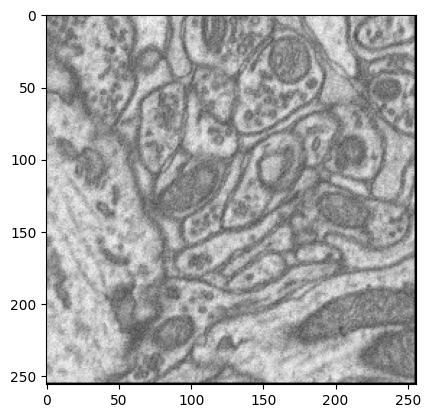

In [6]:
import matplotlib.pyplot as plt
plt.imshow(images[0], cmap='gray')

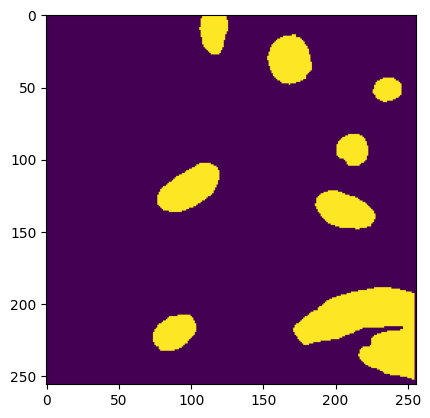

In [7]:
plt.imshow(masks[0])

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, masks, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [ ]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

This code splits the dataset into three distinct parts:

Training Set (```X_train```): 70% of the data used to actually train and update the model's weights.

Validation Set (```X_val```): 15% of the data used to evaluate the model during training to track progress, tune parameters, and save the best epoch without overfitting.

Testing Set (```X_test```): The final 15% of the data kept completely unseen until the very end to give an unbiased evaluation of the model's real-world performance.

## 2. Make the Data Pytorch-ready! (10 points)

In [9]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [11]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([])

In [ ]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

This sets up Data Augmentation for the training data. During training, it randomly applies horizontal flips, vertical flips, and 90-degree rotations (each with a 50% chance). This artificially increases the size and diversity of the training dataset, helping to prevent the U-Net from overfitting to specific orientations of mitochondria. The validation set is intentionally left empty (```A.Compose([])```) because we want to evaluate the model on true, unaltered images.

In [12]:
class MitoDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # add channel dimension: (H, W) -> (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [13]:
train_dataset = MitoDataset(X_train, y_train, transform=train_transform)
val_dataset = MitoDataset(X_val, y_val, transform=val_transform)
test_dataset = MitoDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [ ]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

```MitoDataset```: Wraps the numpy arrays and transforms into PyTorch Dataset objects, so custom Dataset class (```MitoDataset```) can fetch a single image and apply the augmentations on the fly.

```DataLoader```: Wraps the datasets to automate the feeding process during training. It batches the data (16 images at a time), shuffles the training data so the network doesn't memorize the order, and uses multiprocessing (```num_workers=2```) to quickly load the data onto the GPU without bottlenecking the training loop. ```batch_size``` defines how many mini-batches are to be processed and we don't apply shuffle to validation and test to keep the original data for evaluation.

## 3. Configure the Classifier! (30 points)

In [ ]:
#
# SETUP U-NET
#
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

In [ ]:
# DICE LOSS FUNCTION
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# DICE METRIC
def dice_score(pred, target, threshold=0.5, eps=1e-7):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

In [ ]:
# SINGLE EPOCH, PYTORCH IS A BIT MORE COMPLEX HERE..
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images_batch, masks_batch in loader:
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        with torch.set_grad_enabled(training):
            preds = model(images_batch)
            loss = loss_fn(preds, masks_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks_batch)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

## 4. Train the U-Net! (20 points)

In [ ]:
#
# TRAINING LOOP
#
num_epochs = 10

train_losses, val_losses = [], []
train_dices, val_dices = [], []

best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice:", best_val_dice)

In [ ]:
# TODO: Plot the loss and dice curves!
# TODO: YOUR CODE

In [ ]:
# TODO: Do these plots look good?
# TODO: YOUR ANSWER

## 5. Testing the U-Net. (20 points)

In [ ]:
# EVALUATE THE MODEL ON THE TEST DATA
model.load_state_dict(torch.load("best_mito_model.pth", map_location=device))
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

In [ ]:
# Scores are good but let's do some Detective Work to see if
# the classifier actually works well!

# RUN PREDICTIONS
model.eval()

images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds = model(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

images_batch = images_batch.cpu().numpy()
masks_batch = masks_batch.numpy()
preds = preds.cpu().numpy()

In [ ]:
# SHOW EXAMPLE PREDICTIONS OF THE TEST SET
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Interpretation. (10 points)

In [ ]:
# TODO: Do you think the classifier works well?
# TODO: YOUR ANSWER

## Bonus: Improve the results. (33 points)

In [ ]:
# Try to get better performance and show an improved Dice score on the test set!
# TODO: YOUR CODE!

In [ ]:
#
# You made it!!
#
#                 _ ___                /^^\ /^\  /^^\_
#     _          _@)@) \            ,,/ '` ~ `'~~ ', `\.
#   _/o\_ _ _ _/~`.`...'~\        ./~~..,'`','',.,' '  ~:
#  / `,'.~,~.~  .   , . , ~|,   ,/ .,' , ,. .. ,,.   `,  ~\_
# ( ' _' _ '_` _  '  .    , `\_/ .' ..' '  `  `   `..  `,   \_
#  ~V~ V~ V~ V~ ~\ `   ' .  '    , ' .,.,''`.,.''`.,.``. ',   \_
#   _/\ /\ /\ /\_/, . ' ,   `_/~\_ .' .,. ,, , _/~\_ `. `. '.,  \_
#  < ~ ~ '~`'~'`, .,  .   `_: ::: \_ '      `_/ ::: \_ `.,' . ',  \_
#   \ ' `_  '`_    _    ',/ _::_::_ \ _    _/ _::_::_ \   `.,'.,`., \-,-,-,_,_,
#    `'~~ `'~~ `'~~ `'~~  \(_)(_)(_)/  `~~' \(_)(_)(_)/ ~'`\_.._,._,'_;_;_;_;_;
#